# Chapter 3. Once nothing counts twice, is every booked order still in the report, and can every rupee between booked and posted be named?

**Week 2, Tuesday · Chapter 3 of 6 · Booked against collected.**

> **The client asks.** "Booked revenue is not collected revenue. Some orders are paid in two
> instalments, some are refunded, some were never paid at all. Show me, order by order, what we
> actually collected against what we booked in Q2. If there is a gap, I want to know which orders
> and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

The data platform lead added the payments table to the team's access and said, in passing, that
the payments feed "sometimes double-posts when the gateway retries".

**Who needs the answer.** Anand asked which orders make the gap, so an order missing from the report is an order nobody chases, and Anand's analyst reads the reconciliation written above the number before the number itself. A report that loses an order and carries a repeated payment can show a surplus, or a gap that looks closed, and nobody chases an order on a page that reads fully collected.

**The questions on the way.**
1. Which of four proofs shows Anand the gap is honest, and which runs first?
2. Once payments are one row per order, can the report gain rows, or only lose them?
3. What does a first draft with a plain JOIN report on the invented tables?
4. Which check catches the dropped order without reading a rupee?
5. Which moves carry booked to what the feed posted, and does the bridge close on Kalpa's Q2?
6. Does collected come out the same when each order's posted cash is capped at its booked amount?

**The metric at stake.** The gap between booked and collected is at stake, with what can sit inside it: orders never paid, orders paid short and payments posted twice. Collected is the cash that arrived, each payment counted once; posted is every payment row the feed holds, repeats included.

**What came before, and what this adds.** Chapter 2 found that the first draft of collected, Rs 19,29,04,410 against Rs 9,84,00,000 booked, counted every two-instalment order twice, and fixed it by bringing payments to one row per order before the join: 462 Q2 orders in, 462 rows out, booked equal to Monday's figure, and a `posted` column holding what the feed recorded against each order. This chapter proves the fixed report kept every order and names every rupee between booked and posted.

**Setup.** The next cell finds the helper, connects to the warehouse and creates the invented tables
of chapter 1. Every query below is also in `sql/C2_W02_D02_03_every_order_there_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from decimal import Decimal

TINY = """DROP TABLE IF EXISTS pg_temp.tiny_orders, pg_temp.tiny_payments;
CREATE TEMP TABLE tiny_orders (
    order_id  text PRIMARY KEY,
    channel   text NOT NULL,
    amount    numeric(12, 2) NOT NULL
);
CREATE TEMP TABLE tiny_payments (
    payment_id    text PRIMARY KEY,
    order_id      text NOT NULL,
    paid_date     date NOT NULL,
    amount        numeric(12, 2) NOT NULL,
    instalment_no integer NOT NULL
);
INSERT INTO tiny_orders VALUES
    ('T-1', 'app',   1000),
    ('T-2', 'web',   2000),
    ('T-3', 'store', 1500),
    ('T-4', 'app',    800),
    ('T-5', 'store',  500);
INSERT INTO tiny_payments VALUES
    ('P-1', 'T-1', '2026-07-03', 1000, 1),
    ('P-2', 'T-2', '2026-07-05', 1200, 1),
    ('P-3', 'T-2', '2026-08-05',  800, 2),
    ('P-4', 'T-3', '2026-07-09', 1500, 1),
    ('P-5', 'T-3', '2026-07-09', 1500, 1),
    ('P-6', 'T-5', '2026-07-12',  500, 1),
    ('P-7', 'T-9', '2026-07-14',  600, 1);"""

conn = kit.connect()
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute(TINY)            # invented, TEMP, so they vanish when this notebook stops


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def one(query, params=None):
    """The first value of the first row, for a query that returns a single number."""
    row = run(query, params)[0]
    return next(iter(row.values()))


def show(rows, caption="", money=()):
    """Rows as the kit's table; columns named in money print as rupees."""
    if not rows:
        return kit.table(["result"], [["no rows"]], caption)
    heads = list(rows[0])
    body = []
    for r in rows:
        line = []
        for h in heads:
            v = r[h]
            if v is None:
                line.append("NULL")
            elif h in money:
                line.append(kit.rupees(v))
            elif isinstance(v, Decimal):
                line.append(f"{int(v):,}" if v == v.to_integral_value() else f"{float(v):,.2f}")
            else:
                line.append(str(v))
        body.append(line)
    kit.table(heads, body, caption)

print("Invented: T-1 to T-5 booked 5,800 in all; P-1 to P-7 are the feed's rows.")

Invented: T-1 to T-5 booked 5,800 in all; P-1 to P-7 are the feed's rows.


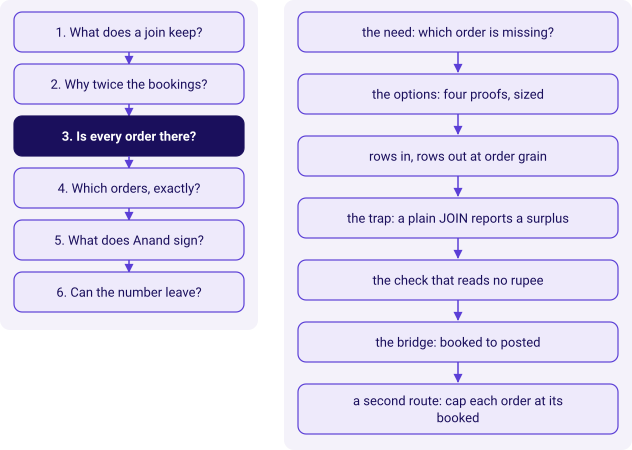

In [2]:
kit.side_by_side(
    kit.ladder(['What does a join keep?', 'Why twice the bookings?', 'Is every order there?', 'Which orders, exactly?', 'What does Anand sign?', 'Can the number leave?'], lit=2, show=False),
    kit.vflow(['the need: which order is missing?', 'the options: four proofs, sized', 'rows in, rows out at order grain', 'the trap: a plain JOIN reports a surplus', 'the check that reads no rupee', 'the bridge: booked to posted', 'a second route: cap each order at its booked'], show=False),
)

## Why is a missing order worse for Anand than a wrong total?

A wrong total is visible: it disagrees with Monday's booked figure, or it breaks a rule such as cash
exceeding bookings, and someone asks. A missing order is invisible, because every number left in the
report is correct for the orders that remain. Anand asked "which orders", and the one order a report
drops is precisely the order his collections team never rings. When a repeated payment inside
collected offsets the dropped order, the report can show a surplus, or a gap that looks closed, and
either reads as "fully collected". The retail story behind Anand's role, how a sale becomes cash and who checks it, is in the domain dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, sections 3 and 4.

**Who else faces this.** Stripe's payout reconciliation report lets a merchant match each payout
in the bank with "the batches of payments and other transactions that they relate to", itemizing
every payment, refund, dispute and fee inside it (Stripe documentation, Payout reconciliation report,
checked 1 Oct 2026). The public case of a missing-row failure is Public Health England, which left
15,841 positive COVID-19 cases out of the daily figures reported between 25 September and 2 October
2020 (PHE statement, GOV.UK, 4 October 2020). The results arrived as CSV files and were pulled into
Excel templates in the old XLS format; each result took several rows, so a template held about 1,400
cases, and once it was full further cases were left off (BBC News, 5 October 2020; both checked 1 Oct
2026). No row that arrived was wrong; what was lost were the rows that never loaded, which is what a
count of rows sent against rows loaded measures.

**The two invented tables.** They hold five orders and seven payments, invented to carry every
case Anand named and the one the platform lead mentioned, so every row can be checked by hand:

| order_id | channel | amount | What happened to it |
|---|---|---|---|
| T-1 | app | 1,000 | Paid once, in full (P-1) |
| T-2 | web | 2,000 | Paid in two instalments, 1,200 and 800 (P-2, P-3) |
| T-3 | store | 1,500 | Paid once, and the gateway posted that payment twice (P-4, P-5) |
| T-4 | app | 800 | Never paid |
| T-5 | store | 500 | Paid once, in full (P-6) |

P-7 is a payment of 600 against T-9, an order that is not in the orders table.

## Which of four proofs shows Anand the gap is honest, and what does each catch?

A team could prove the report in four ways before Anand reads it. The cell below runs each one
against a first draft on the invented tables that carries two errors at once: it joined with a
plain JOIN, and it counts T-3's repeated payment inside collected.

| Option | What Anand reads | What it assumes |
|---|---|---|
| A. One number, booked less posted | A single gap | That the join kept every order and posted nothing twice |
| B. The count reconciliation: rows in, rows out, the difference named | Four comment lines above the number | That a correct count means a correct total |
| C. The bridge: booked, each move named, down to what the feed posted, with a list behind each move | Five bars and the lists | That every move has a definition |
| D. The whole statement, one line per order | Every order | That someone reads every line |

Option,What it shows on the draft,Lines Anand reads,Catches the dropped order,Catches the repeat inside
A. one number,"gap -1,500",1,no,no
B. count reconciliation,4 of 5 orders,4,yes,no
C. the bridge with its lists,"never paid 800, posted twice 1,500",5 bars and 2 lists,yes,yes
D. the whole statement,"5 lines, T-4 empty, T-3 twice",every line,if read,if read


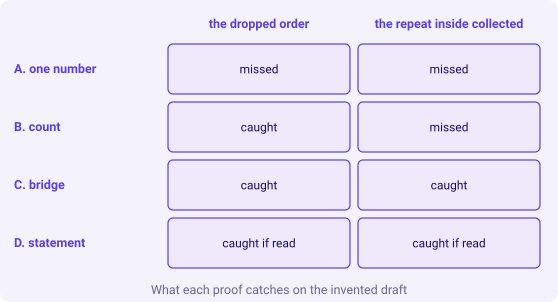

In [3]:
draft = run("""
WITH posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT count(*) AS orders, sum(o.amount) AS booked, sum(pp.posted) AS posted,
       sum(o.amount) - sum(pp.posted) AS gap
FROM tiny_orders o
JOIN posted_per_order pp ON pp.order_id = o.order_id""")[0]
tiny_orders_n = one("SELECT count(*) FROM tiny_orders")
tiny_booked = one("SELECT sum(amount) FROM tiny_orders")
sizing = [
    ("A. one number", f'gap {int(draft["gap"]):,}', "1", "no", "no"),
    ("B. count reconciliation", f'{draft["orders"]} of {tiny_orders_n} orders', "4", "yes", "no"),
    ("C. the bridge with its lists", "never paid 800, posted twice 1,500", "5 bars and 2 lists", "yes", "yes"),
    ("D. the whole statement", "5 lines, T-4 empty, T-3 twice", "every line", "if read", "if read"),
]
kit.table(["Option", "What it shows on the draft", "Lines Anand reads", "Catches the dropped order",
           "Catches the repeat inside"], sizing, caption="Four proofs, run against a draft with two errors")
kit.matrix(["A. one number", "B. count", "C. bridge", "D. statement"],
           ["the dropped order", "the repeat inside collected"],
           [["missed", "missed"], ["caught", "missed"], ["caught", "caught"], ["caught if read", "caught if read"]],
           title="What each proof catches on the invented draft")
kit.check("the draft reports fewer orders than the table holds", draft["orders"] < tiny_orders_n,
          f'{draft["orders"]} of {tiny_orders_n}')

**The best-fit call.** Run B, then C: the count reconciliation first, because it needs no rupee and
catches a dropped or repeated order in one line, then the bridge, because it is the only proof here
that separates an unpaid order from a payment posted twice and puts a list of orders behind each
move. A single number hides both errors, and the whole statement catches everything only if Anand's
analyst reads 462 lines. All four cost seconds to compute, so they differ in what the reader can
check.

**The fact that would change the call.** If Anand's analyst had to tick every order for the audit
file at the quarter's close, D would travel with the report as an appendix; chapter 4's two lists
are its short form.

## 1. Once payments are one row per order, can the report gain rows, or only lose them?

**Predict before you run.** After chapter 2's fix, `payments` meets `orders` one row per order.
What can the join now do to the row count? a) gain rows, whenever an order has two instalments;
b) only lose rows, and only if the join drops an order; c) nothing, a join always returns the left
table's rows; d) gain rows, whenever a payment has no order.

Reconciliation line,What it says on Kalpa's Q2
Rows in,"462 Q2 orders, Rs 9,84,00,000 booked, from orders alone"
Rows out,"462 rows, 462 distinct orders, at order grain"
Booked after the join,"Rs 9,84,00,000, equal to booked before it"
The gap,"booked less collected, each rupee named: yours to fill in level 5"


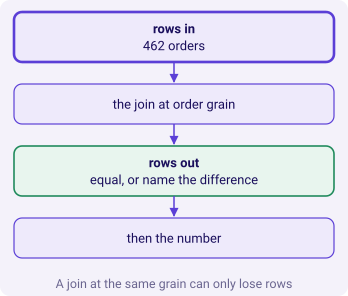

In [4]:
grain_q2 = run("""
WITH posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM payments
    GROUP BY order_id
)
SELECT count(*) AS rows_out, count(DISTINCT o.order_id) AS orders_out, sum(o.amount) AS booked
FROM orders o
LEFT JOIN posted_per_order pp ON pp.order_id = o.order_id
WHERE o.quarter = 'Q2'""")[0]
booked_q2 = one("SELECT sum(amount) FROM orders WHERE quarter = 'Q2'")
orders_q2 = one("SELECT count(*) FROM orders WHERE quarter = 'Q2'")
kit.table(["Reconciliation line", "What it says on Kalpa's Q2"],
          [("Rows in", f"{orders_q2} Q2 orders, {kit.rupees(booked_q2)} booked, from orders alone"),
           ("Rows out", f'{grain_q2["rows_out"]} rows, {grain_q2["orders_out"]} distinct orders, at order grain'),
           ("Booked after the join", f'{kit.rupees(grain_q2["booked"])}, equal to booked before it'),
           ("The gap", "booked less collected, each rupee named: yours to fill in level 5")],
          caption="The reconciliation, written above the number")
kit.vflow(["rows in\n462 orders", "the join at order grain", "rows out\nequal, or name the difference",
           "then the number"], kinds=["known", "plain", "good", "plain"],
          title="A join at the same grain can only lose rows")

**What happened.** The answer is b. A row of `orders` now meets at most one row of payments, so no
order can come out twice; the only way the count can move is down, when the join drops an order
that found no match. On Kalpa's Q2 the LEFT JOIN returns 462 rows for 462 orders and booked after
the join equals Rs 9,84,00,000, so nothing was dropped or repeated.

In [5]:
kit.check("rows out equal rows in at order grain", grain_q2["rows_out"] == orders_q2,
          f'{grain_q2["rows_out"]} out, {orders_q2} in')
kit.check("no order appears twice", grain_q2["orders_out"] == grain_q2["rows_out"], f'{grain_q2["orders_out"]}')
kit.check("booked after the join equals booked from orders alone", grain_q2["booked"] == booked_q2,
          kit.rupees(booked_q2))

## 2. What does a first draft with a plain JOIN report on the invented tables?

**The plausible wrong answer.** A teammate takes chapter 2's fix and writes `JOIN`, which in SQL
means INNER JOIN, instead of `LEFT JOIN`: a very common first draft, since `JOIN` is the shortest
thing to type. Payments are one row per order, so nothing is counted twice by the join.

```sql
WITH posted_per_order AS (
    SELECT order_id, sum(amount) AS posted FROM tiny_payments GROUP BY order_id
)
SELECT count(*) AS orders, sum(o.amount) AS booked, sum(pp.posted) AS posted,
       sum(o.amount) - sum(pp.posted) AS gap
FROM tiny_orders o
JOIN posted_per_order pp ON pp.order_id = o.order_id;
```

**Predict before you run.** Booked across the five invented orders is 5,800. What gap does the draft
report? a) 800; b) 0; c) minus 1,500; d) minus 700.

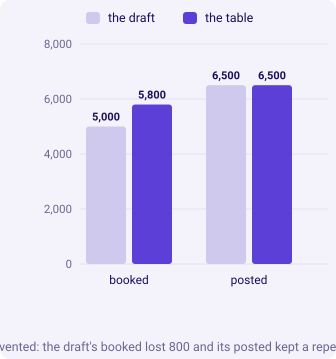

In [6]:
kit.stats([(f'{draft["orders"]}', "orders in the report", "of 5 in the table"),
           (f'{int(draft["booked"]):,}', "booked, as reported", "of 5,800"),
           (f'{int(draft["posted"]):,}', "posted, as reported", "every payment row matched"),
           (f'{int(draft["gap"]):,}', "gap, as reported", "reads as fully collected, with a surplus")])
kit.columns(["booked", "posted"], [("the draft", [float(draft["booked"]), float(draft["posted"])]),
                                   ("the table", [float(tiny_booked), float(draft["posted"])])],
            title="Invented: the draft's booked lost 800 and its posted kept a repeat")

**What happened.** The answer is c: four orders, booked 5,000, posted 6,500, a gap of minus 1,500. The
report says Kalpa collected everything it booked and 1,500 more.

**Why it is wrong.** Two errors cancel into a comfortable number. The plain JOIN dropped T-4, the
one order nobody paid, so 800 of booked vanished with it; and T-3's payment, posted twice by the
gateway, puts 1,500 inside posted that never came in twice. Anand, reading "no gap, and a surplus",
stops chasing T-4 and never asks why the feed shows more cash than was booked.

## 3. Which check catches the dropped order without reading a rupee?

**The check that catches it.** Count the orders in the report against the orders in the table. The
report holds 4; the table holds 5. The count needs no rupee at all, which is why it runs first and
every time: a LEFT JOIN at order grain must return exactly the orders it was given.

**The fix, and what changed.** `LEFT JOIN` in place of `JOIN` brings T-4 back, with NULL where its
posted cash would be.

In [7]:
fixed = run("""
WITH posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT count(*) AS orders, sum(o.amount) AS booked, sum(pp.posted) AS posted,
       sum(o.amount) - sum(pp.posted) AS gap
FROM tiny_orders o
LEFT JOIN posted_per_order pp ON pp.order_id = o.order_id""")[0]
kit.table(["Draft", "Orders", "Booked", "Posted", "Gap"],
          [("plain JOIN", draft["orders"], f'{int(draft["booked"]):,}', f'{int(draft["posted"]):,}', f'{int(draft["gap"]):,}'),
           ("LEFT JOIN", fixed["orders"], f'{int(fixed["booked"]):,}', f'{int(fixed["posted"]):,}', f'{int(fixed["gap"]):,}')],
          caption="Invented: the LEFT JOIN brings back T-4; the gap is still one number for two things")
kit.check("the count check fails the plain JOIN draft", draft["orders"] != tiny_orders_n,
          f'{draft["orders"]} of {tiny_orders_n}')
kit.check("the LEFT JOIN keeps all five orders and all 5,800 of booked",
          fixed["orders"] == tiny_orders_n and fixed["booked"] == tiny_booked, f'{fixed["orders"]} orders')

Draft,Orders,Booked,Posted,Gap
plain JOIN,4,"5,000","6,500","-1,500"
LEFT JOIN,5,"5,800","6,500",-700


**What happened.** The LEFT JOIN keeps all five orders and all 5,800 of booked, and the count closes.
The gap now reads minus 700, which is still wrong: it is 800 never paid less 1,500 posted twice, two
different things netted into one figure that describes neither. The next level separates them.

**Your turn.** Run the plain JOIN version on Kalpa's Q2 and count its orders against the 462 in the
quarter. Type this in the empty cell below and write what you see in your reconciliation lines,
before you read any rupee:

```python
kalpa_inner = run("""
WITH posted_per_order AS (SELECT order_id, sum(amount) AS posted FROM payments GROUP BY order_id)
SELECT count(*) AS orders, sum(o.amount) AS booked, sum(pp.posted) AS posted
FROM orders o JOIN posted_per_order pp ON pp.order_id = o.order_id
WHERE o.quarter = 'Q2'""")[0]
print(kalpa_inner["orders"], "orders against", orders_q2)
```

## 4. Which moves carry booked to what the feed posted?

A bridge walks from one total to another in named moves, each with the list of orders behind it,
which is Week 1 Wednesday's revenue bridge one tool later. From booked to posted there are three
moves, and each has a definition that a query can compute order by order:

| Move | Definition, per order | Invented tables |
|---|---|---|
| Never paid | Booked, where the order has no payment row at all | T-4, 800 |
| Paid short | Booked less collected, where collected is below booked | none |
| Posted twice | Posted less collected: the same instalment written more than once | T-3, 1,500 |

Collected counts each order and instalment once, at its amount; posted adds every row the feed holds.
So booked, less never paid, less paid short, is collected; and collected, plus posted twice, is
posted.

**Predict before you run.** On the invented tables, what is collected, each payment counted once?
a) 6,500; b) 5,800; c) 5,000; d) 4,200.

order_id,channel,booked,collected,posted
T-1,app,"1,000","1,000","1,000"
T-2,web,"2,000","2,000","2,000"
T-3,store,"1,500","1,500","3,000"
T-4,app,800,NULL,NULL
T-5,store,500,500,500


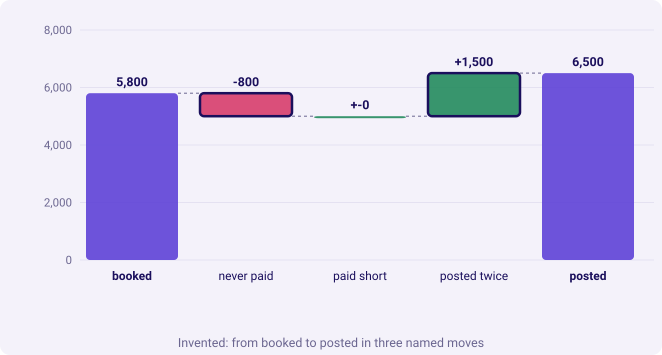

In [8]:
tiny_rows = run("""WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM tiny_payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM tiny_orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
ORDER BY o.order_id""")
show(tiny_rows, "Invented: booked, collected and posted, one row per order")
tb = run("""WITH per_order AS (
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM tiny_payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM tiny_orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
)
SELECT sum(booked)                                                    AS booked,
       sum(booked) FILTER (WHERE collected IS NULL)                   AS never_paid,
       coalesce(sum(booked - collected) FILTER (WHERE collected < booked), 0) AS paid_short,
       sum(collected)                                                 AS collected,
       sum(posted - collected)                                        AS posted_twice,
       sum(posted)                                                    AS posted
FROM per_order""")[0]
tb = {k: (v or 0) for k, v in tb.items()}
kit.bridge(("booked", float(tb["booked"])),
           [("never paid", -float(tb["never_paid"])), ("paid short", -float(tb["paid_short"])),
            ("posted twice", float(tb["posted_twice"]))],
           end_label="posted", fmt=lambda v: f"{v:,.0f}", lit=[0, 2],
           title="Invented: from booked to posted in three named moves")

**What happened.** The answer is c, 5,000: T-1's 1,000, T-2's two instalments of 1,200 and 800, T-3's
one instalment of 1,500 counted once, and T-5's 500. The bridge reads booked 5,800, less 800 never
paid (T-4), less nothing paid short, is collected 5,000; plus 1,500 posted twice (T-3's instalment
1 written a second time) is posted 6,500. Each move has one order behind it, and each is a question
for a different person: T-4 for the collections team, T-3 for the platform lead.

In [9]:
kit.check("booked less never paid less paid short equals collected",
          tb["booked"] - tb["never_paid"] - tb["paid_short"] == tb["collected"], f'{int(tb["collected"]):,}')
kit.check("collected plus posted twice equals posted", tb["collected"] + tb["posted_twice"] == tb["posted"],
          f'{int(tb["posted"]):,}')
kit.check("posted equals the payment rows that match a booked order",
          tb["posted"] == one("SELECT sum(amount) FROM tiny_payments WHERE order_id IN (SELECT order_id FROM tiny_orders)"),
          f'{int(tb["posted"]):,}')

## 5. Does the bridge close on Kalpa's Q2?

**Your turn.** The same bridge on the warehouse is the reconciliation Anand's analyst will audit. In
the empty cell below, type these lines, run them, and copy the six figures into your reconciliation
lines before reading them aloud:

```python
kb = run(Q_BRIDGE)[0]
for move, value in kb.items():
    print(f"{move:>13}: {kit.rupees(value or 0)}")
```

`Q_BRIDGE` is defined in the cell after it, which also checks, without printing any figure, that
your bridge closes.

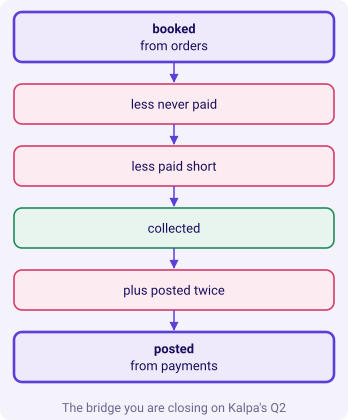

In [10]:
Q_BRIDGE = """WITH per_order AS (
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
)
SELECT sum(booked)                                                    AS booked,
       sum(booked) FILTER (WHERE collected IS NULL)                   AS never_paid,
       coalesce(sum(booked - collected) FILTER (WHERE collected < booked), 0) AS paid_short,
       sum(collected)                                                 AS collected,
       sum(posted - collected)                                        AS posted_twice,
       sum(posted)                                                    AS posted
FROM per_order"""
kb = {k: (v or 0) for k, v in run(Q_BRIDGE)[0].items()}
posted_alone = one("""
SELECT sum(amount) AS posted
FROM payments
WHERE order_id IN (SELECT order_id FROM orders WHERE quarter = 'Q2')""")
kit.vflow(["booked\nfrom orders", "less never paid", "less paid short", "collected",
           "plus posted twice", "posted\nfrom payments"],
          kinds=["known", "bad", "bad", "good", "bad", "known"], title="The bridge you are closing on Kalpa's Q2")
kit.check("Kalpa's booked in the bridge equals Monday's", kb["booked"] == booked_q2, kit.rupees(booked_q2))
kit.check("booked less never paid less paid short equals collected, on Kalpa's Q2",
          kb["booked"] - kb["never_paid"] - kb["paid_short"] == kb["collected"], "equal to the rupee")
kit.check("collected plus posted twice equals posted, on Kalpa's Q2",
          kb["collected"] + kb["posted_twice"] == kb["posted"], "equal to the rupee")
kit.check("the bridge's posted equals the payments table's own total for Q2 orders",
          kb["posted"] == posted_alone, "equal to the rupee")

**What happened.** The four checks pass: the bridge starts at Monday's Rs 9,84,00,000, closes at each
step, and lands on what the payments table holds against Q2's orders, counted without a join. The
figures in between are yours, from the cell above; each move now needs the list of orders behind
it, which is chapter 4.

Kavya Nair, the team's senior analyst, reviews every number before it leaves the team.

> **Kavya's review.** "Rows in, rows out and the difference explained, written above the number. If
> the count does not close, the number does not leave the team, and if the gap has two causes, it
> gets two bars."

## Does collected come out the same when each order's posted cash is capped at its booked amount?

The bridge counted collected by instalment: each order and instalment once. A second method never
looks at instalment numbers at all. For every order that was paid, it takes the smaller of what the
feed posted and what was booked, since no order can honestly collect more than it was booked for,
and adds those up. Here the INNER JOIN is the honest choice, because the question is about paid
orders only; an unpaid order adds nothing to collected either way.

The two methods fail in different places: the instalment method would count a retry that the feed
wrote under a new instalment number, and the cap method would throw away a genuine overpayment.
Agreement rules out either one alone. It cannot rule out a retry under a new instalment number on an
order that is also paid short, which both methods count, or two errors that happen to be the same
size.

order_id,booked,posted,capped
T-1,"1,000","1,000","1,000"
T-2,"2,000","2,000","2,000"
T-3,"1,500","3,000","1,500"
T-5,500,500,500


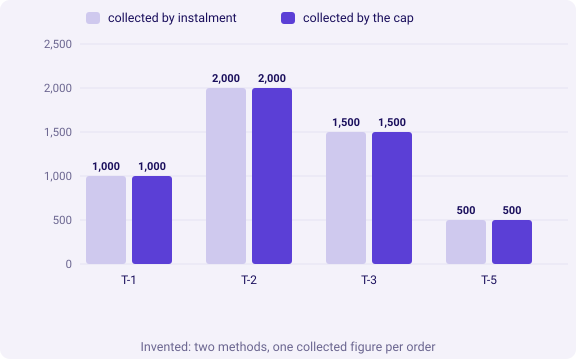

In [11]:
cap_rows = run("""
WITH posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT o.order_id, o.amount AS booked, pp.posted, least(pp.posted, o.amount) AS capped
FROM tiny_orders o
JOIN posted_per_order pp ON pp.order_id = o.order_id
ORDER BY o.order_id""")
show(cap_rows, "Invented: each paid order's posted cash, capped at its booked amount")
by_cap = sum(r["capped"] for r in cap_rows)
kit.columns([r["order_id"] for r in cap_rows],
            [("collected by instalment", [float(next(t["collected"] for t in tiny_rows if t["order_id"] == r["order_id"])) for r in cap_rows]),
             ("collected by the cap", [float(r["capped"]) for r in cap_rows])],
            title="Invented: two methods, one collected figure per order")
kit.check("the cap method reaches the bridge's collected on the invented tables", by_cap == tb["collected"],
          f"{int(by_cap):,}")
kalpa_cap = one("""
WITH posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM payments
    GROUP BY order_id
)
SELECT sum(least(pp.posted, o.amount)) AS collected_by_cap
FROM orders o
JOIN posted_per_order pp ON pp.order_id = o.order_id
WHERE o.quarter = 'Q2'""")
kit.check("the cap method reaches the bridge's collected on Kalpa's Q2", kalpa_cap == kb["collected"],
          "equal to the rupee")

**What happened.** Both methods give 5,000 on the invented tables, order by order, and they agree to
the rupee on Kalpa's Q2. So the feed holds no retry under a new instalment number and no genuine
overpayment, and collected can be trusted on either count.

### In the interview: how do you reconcile a joined total, and find two errors that cancel?

The tags mark how often a question comes up: [S] a staple asked everywhere, [F] frequent in GCC and product screens, [D] a differentiator.

**[F] How do you reconcile a total after a join back to its source table?** Recompute the total from the source table alone, without the join, and compare. Booked after the
join must equal booked from `orders`; posted after the join must equal the payments table's own
total for the same orders. Any difference is explained as a named move in a bridge, with the rows
behind it listed, or the join is wrong.

**[D] Two errors cancel and the total looks right: how would you find them?** A total cannot prove itself, so count first: rows in against rows out finds a dropped or
repeated row even when the rupees balance. Then split the difference into moves that each have a
definition, so an unpaid order and a repeated payment each get their own bar, and each bar is checked
against the list of orders behind it.

### Depth: why does a bridge list its moves in a fixed order?

The bars in between depend on the order. Starting from booked, "never paid" is measured on booked
amounts and "posted twice" on posted amounts; list them in another order and the running totals
between them change even though the ends do not. A finance team fixes the order once and writes it
above the chart, so two analysts produce the same bridge.

## What did this chapter answer, one line per question?

1. The count reconciliation runs first, since it needs no rupee, and the bridge follows, the one
   proof that gives an unpaid order and a repeated payment each its own bar with a list behind it.
2. Once payments are one row per order, the report can lose rows and cannot gain them; on Kalpa's
   Q2 it keeps all 462 orders and Rs 9,84,00,000 of booked.
3. A plain JOIN draft on the invented tables reports 4 orders, booked 5,000, posted 6,500 and a gap
   of minus 1,500: fully collected, with a surplus.
4. Counting orders in the report against the table, 4 against 5, catches it without reading a rupee;
   the LEFT JOIN restores all five, and the gap reads minus 700 until its two causes are separated.
5. Booked 5,800, less 800 never paid, less nothing paid short, is collected 5,000; plus 1,500 posted
   twice is posted 6,500. The same bridge closes on Kalpa's Q2 at every step, and its posted equals
   the payments table's own total for Q2 orders.
6. Capping each paid order's posted cash at its booked amount gives the same collected, 5,000 on the
   invented tables and the same figure on Kalpa's Q2.

**The question this leaves.** Each bar of the bridge is a total, and Anand asked which orders.
Chapter 4 asks which Q2 orders were never paid, and which payments were posted twice.

In [12]:
kit.check_summary()